# CRM Segmentation — Full Pipeline


## 1. Imports & Setup
All required libraries. Run this cell first.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN


sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading

We load the **pre-merged** dataset that combines the four original tables:
`RETAIL_SALES_DETAIL`, `RETAIL_SALES`, `RETAIL_REGISTRY`, `RETAIL_PRODUCT`.

In [2]:
PATH_MERGED = '/Users/sergio/Desktop/SEGMENTATION/Datasets/RETAIL_MERGED.csv'

df = pd.read_csv(PATH_MERGED, low_memory=False)
df['DATE'] = pd.to_datetime(df['DATE'])

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print()
print('Date range:', df['DATE'].min(), '->', df['DATE'].max())
print('Unique customers:', df['CUSTOMER_ID'].nunique())
df.head(3)

Shape: (2047073, 15)
Columns: ['CUSTOMER_ID', 'DATE', 'PRODUCT_ID', 'QUANTITY', 'LIST_PRICE', 'SPECIAL', 'OUTLET_ID', 'PAYMENT_METHOD', 'DAILY_TRANSACTION_COUNT', 'TOTAL_POINTS', 'CREATION_DATE', 'REGIONAL_CODE', 'ORIGIN', 'CATEGORY_ID', 'CATEGORY_DESC']

Date range: 2018-06-30 00:00:00 -> 2020-01-26 00:00:00
Unique customers: 25728


,CUSTOMER_ID,DATE,PRODUCT_ID,QUANTITY,LIST_PRICE,SPECIAL,OUTLET_ID,PAYMENT_METHOD,DAILY_TRANSACTION_COUNT,TOTAL_POINTS,CREATION_DATE,REGIONAL_CODE,ORIGIN,CATEGORY_ID,CATEGORY_DESC
0,BF00404312,2020-01-17,1068,1.0,6.85,N,[14],['CASH'],1.0,-3960.0,2003-04-02,23.0,WEB,3.0,READY-MADE
1,BF00404312,2020-01-17,94580,1.0,6.25,N,[14],['CASH'],1.0,-3960.0,2003-04-02,23.0,WEB,7.0,FISH
2,BF00404312,2020-01-17,224046,1.0,4.95,N,[14],['CASH'],1.0,-3960.0,2003-04-02,23.0,WEB,11.0,FRUIT


## 3. Exploratory Data Analysis

Before touching any data we explore structure, missing values, distributions and anomalies. This step drives every cleaning decision that follows.

In [3]:
print('=== NULL COUNTS ===')
print(df.isna().sum())
print()
print('=== NUMERIC DESCRIBE ===')
df.describe()

=== NULL COUNTS ===
CUSTOMER_ID                   0
DATE                          0
PRODUCT_ID                    0
QUANTITY                      0
LIST_PRICE                    0
SPECIAL                       0
OUTLET_ID                   791
PAYMENT_METHOD              791
DAILY_TRANSACTION_COUNT     791
TOTAL_POINTS                791
CREATION_DATE              1258
REGIONAL_CODE                 8
ORIGIN                        8
CATEGORY_ID                   0
CATEGORY_DESC              3280
dtype: int64

=== NUMERIC DESCRIBE ===


,DATE,PRODUCT_ID,QUANTITY,LIST_PRICE,DAILY_TRANSACTION_COUNT,TOTAL_POINTS,REGIONAL_CODE,CATEGORY_ID
count,2047073,2.047073e+06,2.047073e+06,2.047073e+06,2.046282e+06,2.046282e+06,2.047065e+06,2.047073e+06
mean,2019-04-21 08:06:27.217456,7.393058e+04,1.136371e+00,8.205163e+00,1.002392e+00,8.479445e+01,3.145070e+01,6.022514e+00
min,2018-06-30 00:00:00,-1.200000e+01,-4.800000e+01,-3.048000e+02,1.000000e+00,-1.469150e+05,1.000000e+00,-1.000000e+00
25%,2018-12-09 00:00:00,2.942000e+03,1.000000e+00,4.950000e+00,1.000000e+00,1.600000e+02,1.300000e+01,3.000000e+00
50%,2019-04-18 00:00:00,4.415400e+04,1.000000e+00,6.950000e+00,1.000000e+00,2.800000e+02,3.000000e+01,6.000000e+00
75%,2019-09-11 00:00:00,1.387850e+05,1.000000e+00,9.950000e+00,1.000000e+00,4.300000e+02,4.700000e+01,1.000000e+01
max,2020-01-26 00:00:00,2.537530e+05,1.000000e+03,3.704500e+02,3.000000e+00,9.180000e+03,8.200000e+01,1.600000e+01
std,NaN,7.768726e+04,1.716446e+00,7.497653e+00,4.912538e-02,1.627408e+03,1.971166e+01,3.990382e+00


### 3.1 Key anomalies identified

| Column | Issue | Count | Decision |
|---|---|---|---|
| `OUTLET_ID` | Stored as `'[14]'` | all rows | Strip brackets |
| `PAYMENT_METHOD` | Stored as `"['CASH']"` | all rows | Strip brackets |
| `PAYMENT_METHOD` | Mixed methods `"['CASH', 'CREDIT CARD']"` | 107 rows | Classify as MIXED (card) |
| `QUANTITY` | Negative values = product returns | 343 | Flag then remove |
| `LIST_PRICE` | Negative, positive QUANTITY = coupon lines | 20,659 | **Keep** as feature |
| `LIST_PRICE` | Zero price = promo / gift items | 58,803 | Keep as-is |
| `PRODUCT_ID = −12` | Bag/voucher line items | 3,277 | Keep, fill CATEGORY as VOUCHER |
| `TOTAL_POINTS` | Negative = loyalty redemption events | 130,867 | **Keep** — split into earned/redeemed features |
| `OUTLET_ID / PAYMENT / DAILY_TXN / TOTAL_POINTS` | All null together | 791 | Drop (no transaction context) |
| `CREATION_DATE / REGIONAL_CODE / ORIGIN` | Registry missing | 1,258 / 8 / 8 | Fill Unknown / −1 |
| `CATEGORY_DESC` | Null for PRODUCT_ID = −12 | 3,280 | Fill 'VOUCHER' |


> **Critical**: negative `LIST_PRICE` with positive `QUANTITY` are **coupon/discount lines**, not returns. Dropping them would remove 20,659 valid transactions and reduce the dataset to 1.97M instead of the correct 2.046M rows.

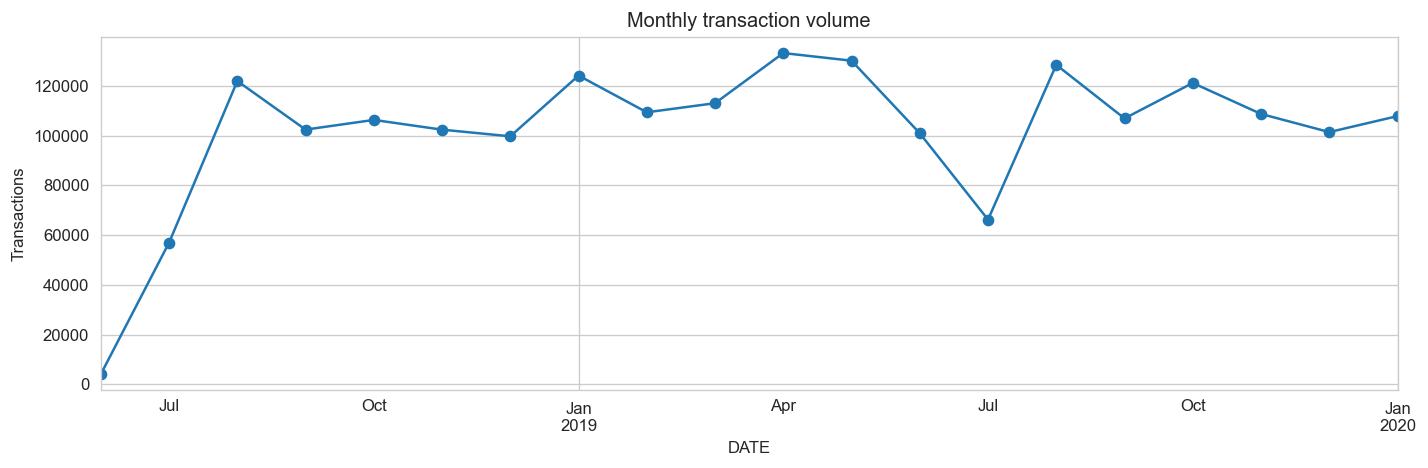

In [4]:
# Monthly transaction volume
monthly = df.groupby(df['DATE'].dt.to_period('M')).size()
monthly.plot(figsize=(12,4), marker='o', title='Monthly transaction volume')
plt.ylabel('Transactions')
plt.tight_layout()
plt.show()

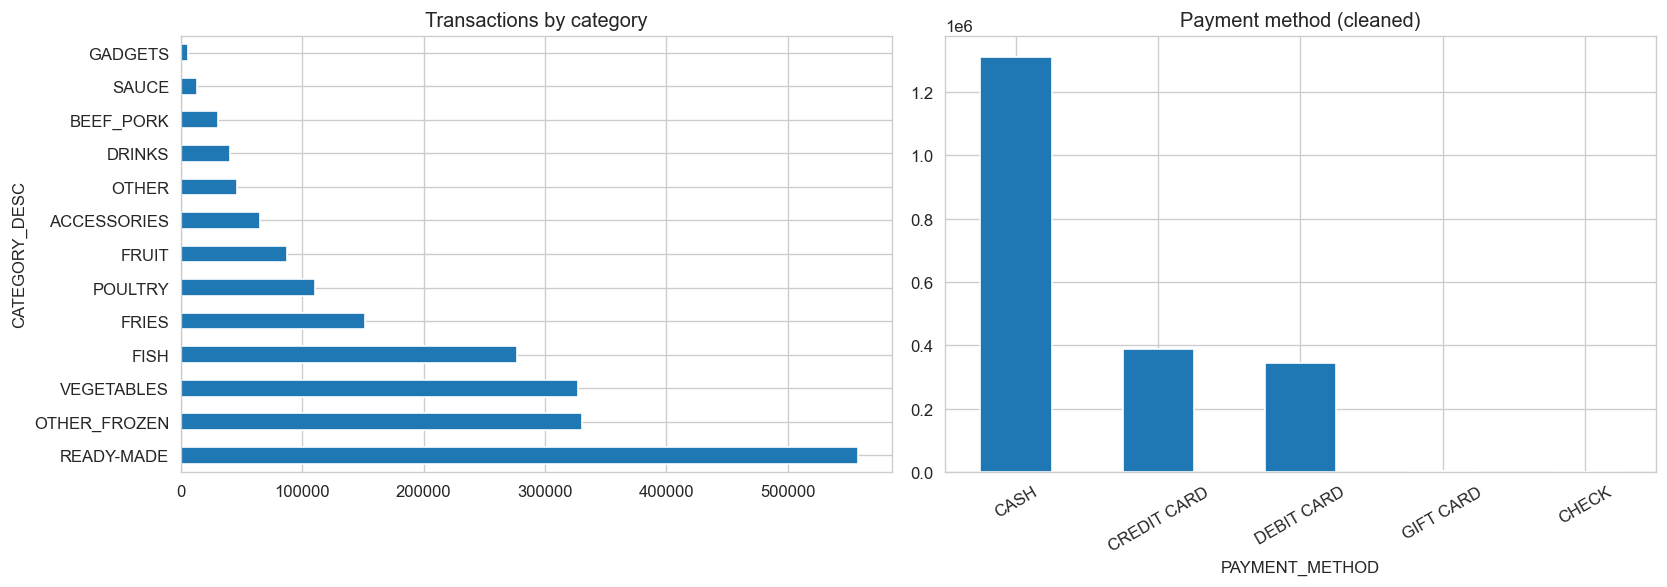

In [5]:
# Category and payment distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['CATEGORY_DESC'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('Transactions by category')

# Strip brackets for readable payment chart
pm_clean = df['PAYMENT_METHOD'].str.strip("[]'").str.split("',").str[0]
pm_clean.value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Payment method (cleaned)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

count    25728.000000
mean        19.002138
std         10.908024
min          1.000000
25%         10.000000
50%         18.000000
75%         28.000000
max        101.000000
Name: DATE, dtype: float64


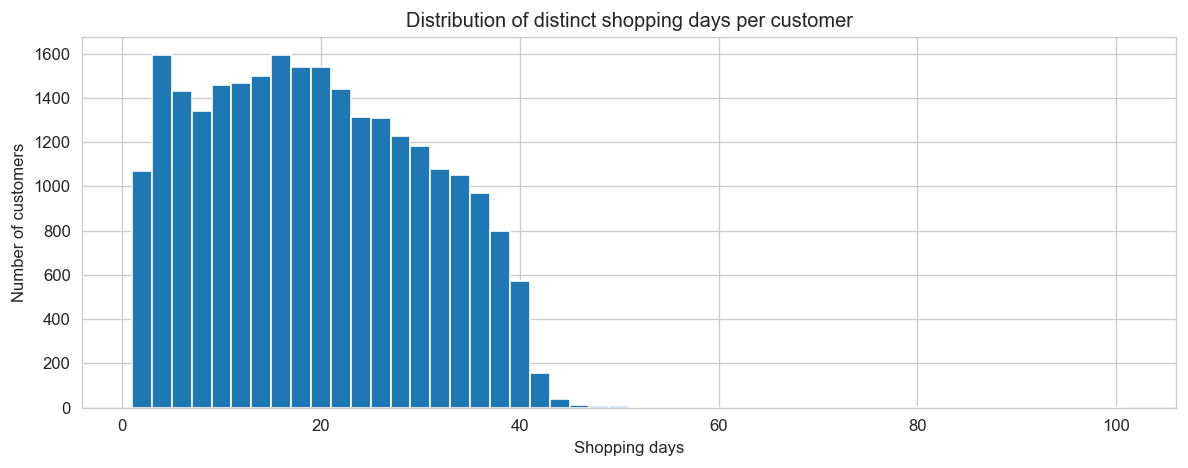

In [6]:
# Customer activity distribution, how many distinct shopping days per customer?
# This tells us how many active vs barely-engaged customers we have.
visits = df.groupby('CUSTOMER_ID')['DATE'].nunique()
print(visits.describe())

visits.hist(bins=50, figsize=(10,4), edgecolor='white')
plt.title('Distribution of distinct shopping days per customer')
plt.xlabel('Shopping days')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

Confirmed promotional events: 3785


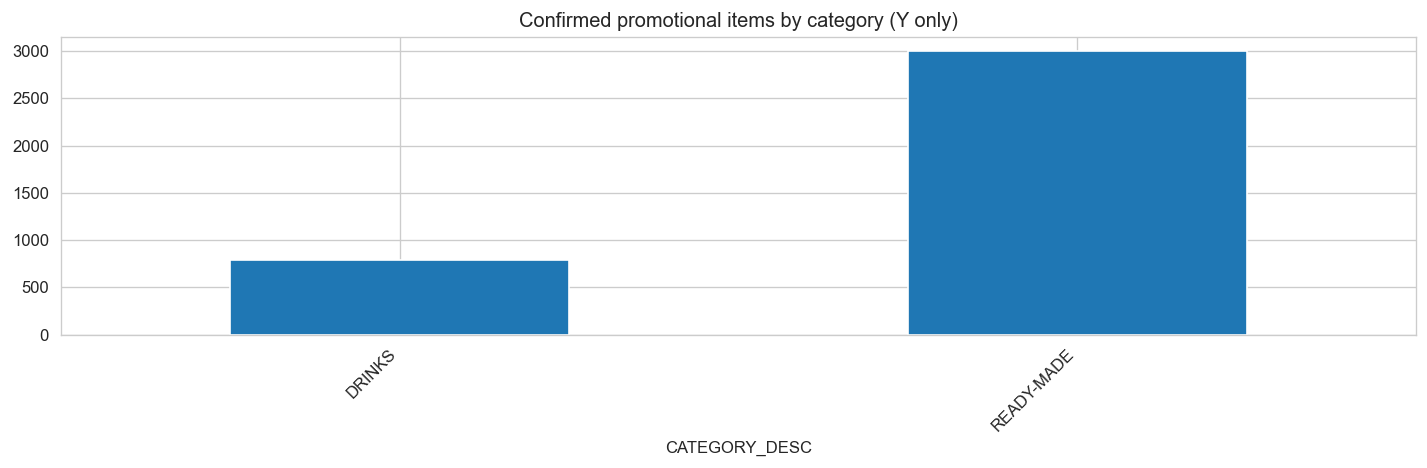

In [7]:
# SPECIAL column: 99.8% NaN filled with 'N' — analyse only confirmed events
# Plotting on the full df would be misleading (we'd be plotting imputed 'N' values)
confirmed_specials = df[df['SPECIAL'] == 'Y']
print('Confirmed promotional events:', len(confirmed_specials))

pd.crosstab(confirmed_specials['CATEGORY_DESC'], confirmed_specials['SPECIAL']) \
  .plot(kind='bar', figsize=(12,4), legend=False,
        title='Confirmed promotional items by category (Y only)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Data Cleaning

Every decision here follows directly from the EDA findings above. We run the cleaning **in a specific order** because some steps depend on others (e.g. we must compute return stats *before* removing return rows).

### 4.1 Column format cleaning

Two columns arrived with list-bracket formatting from the merge. We strip those before anything else so downstream logic is clean.

In [8]:
# OUTLET_ID: '[14]' -> 14.0
# The regex extracts the first digit sequence inside the brackets.
df['OUTLET_ID'] = df['OUTLET_ID'].str.extract(r'(\d+)').astype(float)

# PAYMENT_METHOD: "['CASH']" -> 'CASH'
# Mixed payments "['CASH', 'CREDIT CARD']" are classified as MIXED
# (the customer used at least one non-cash method, so MIXED counts as card=1 in features)
def clean_payment(val):
    if pd.isna(val): return np.nan
    val = str(val).strip("[]' ")
    if 'CASH' in val and ',' not in val: return 'CASH'
    elif ',' in val: return 'MIXED'
    return val.strip("' ")

df['PAYMENT_METHOD'] = df['PAYMENT_METHOD'].apply(clean_payment)

# Fill CATEGORY_DESC for voucher/bag products
df['CATEGORY_DESC'] = df['CATEGORY_DESC'].fillna('VOUCHER')

print('OUTLET_ID sample:', df['OUTLET_ID'].dropna().unique()[:6])
print('PAYMENT_METHOD:', df['PAYMENT_METHOD'].value_counts().to_dict())

OUTLET_ID sample: [14. 94. 81. 85.  8. 89.]
PAYMENT_METHOD: {'CASH': 1311146, 'CREDIT CARD': 389062, 'DEBIT CARD': 343774, 'GIFT CARD': 2180, 'MIXED': 107, 'CHECK': 13}


### 4.2 Flag returns and discount lines at customer level

We compute return and discount statistics before removing any rows, so we don't lose this behavioural signal. These per-customer stats will become features later.

In [9]:
# True return: QUANTITY < 0 (customer brought product back)
# Discount line: LIST_PRICE < 0 but QUANTITY > 0 (coupon applied at item level)
df['IS_RETURN']        = (df['QUANTITY'] < 0).astype(int)
df['IS_DISCOUNT_LINE'] = ((df['QUANTITY'] >= 0) & (df['LIST_PRICE'] < 0)).astype(int)

# Aggregate to customer level — these become features in Section 6
return_counts   = df.groupby('CUSTOMER_ID')['IS_RETURN'].sum().rename('RETURN_COUNT')
return_ratio    = (df.groupby('CUSTOMER_ID')['IS_RETURN'].sum() /
                   df.groupby('CUSTOMER_ID')['IS_RETURN'].count()).rename('RETURN_RATE')
discount_counts = df.groupby('CUSTOMER_ID')['IS_DISCOUNT_LINE'].sum().rename('DISCOUNT_LINE_COUNT')

print('Return rows flagged:', df['IS_RETURN'].sum())
print('Discount line rows flagged:', df['IS_DISCOUNT_LINE'].sum())

Return rows flagged: 343
Discount line rows flagged: 20659


### 4.3 Remove invalid rows

Only two categories of rows are genuinely invalid:
- **343 true returns** (negative QUANTITY): no longer represent a purchase event
- **791 rows** with null `OUTLET_ID / PAYMENT_METHOD`: no transaction context at all

Everything else stays.

In [10]:
df_clean = df[df['QUANTITY'] > 0].copy()            # remove 343 returns
df_clean = df_clean.dropna(subset=['OUTLET_ID', 'PAYMENT_METHOD'])  # remove 791 orphans
print('Clean dataset rows:', len(df_clean))          # expect ~2,046,123
print('Unique customers:', df_clean['CUSTOMER_ID'].nunique())

Clean dataset rows: 2046123
Unique customers: 25728


### 4.4 Fill remaining nulls

- `TOTAL_POINTS`: all items in the same receipt share the same value (confirmed: 0 receipts with 2+ distinct values). We fill nulls with the per-receipt median, then the global median as fallback.
- Registry columns (`ORIGIN`, `CREATION_DATE`, `REGIONAL_CODE`): small missingness from unmatched customers.

In [11]:
# TOTAL_POINTS is receipt-level: group by (CUSTOMER_ID, DATE)
receipt_median = df_clean.groupby(['CUSTOMER_ID','DATE'])['TOTAL_POINTS'].transform('median')
df_clean['TOTAL_POINTS'] = df_clean['TOTAL_POINTS'].fillna(receipt_median)
df_clean['TOTAL_POINTS'] = df_clean['TOTAL_POINTS'].fillna(df_clean['TOTAL_POINTS'].median())

df_clean['ORIGIN']        = df_clean['ORIGIN'].fillna('Unknown')
df_clean['CREATION_DATE'] = df_clean['CREATION_DATE'].fillna('Unknown')
df_clean['REGIONAL_CODE'] = df_clean['REGIONAL_CODE'].fillna(-1)

print('Nulls remaining after cleaning:')
remaining = df_clean.isna().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None')

Nulls remaining after cleaning:
None


## 5. Feature Engineering

We transform the transaction-level dataset (one row per item purchased) into a **customer-level feature matrix** (one row per customer). Every clustering algorithm requires this step — you cannot cluster on raw transactions.

### Feature design rationale

| Feature | Source | Why it matters |
|---|---|---|
| `RECENCY` | Last purchase date | Recent buyers are more engaged |
| `FREQUENCY` | Distinct shopping days | Measures loyalty and habit |
| `MONETARY` | Gross spend (positive prices only) | True purchase value |
| `AVG_BASKET_GROSS` | Mean spend per item | Distinguishes premium vs budget shoppers |
| `CATEGORY_DIVERSITY` | Distinct categories bought | Wide vs narrow shopping behaviour |
| `OUTLET_DIVERSITY` | Distinct stores visited | Loyal to one store vs multi-store shopper |
| `CARD_USAGE_RATE` | Fraction of card payments | Proxy for digitisation and demographics |
| `SPECIAL_RATE` | Fraction of promo items | Promo sensitivity |
| `AVG_PTS_EARNED` | Mean points on earning receipts | Loyalty programme engagement |
| `REDEMPTION_FREQ` | Fraction of receipts with redemption | Active redeemers vs passive earners |
| `DISCOUNT_SENSITIVITY` | Discount spend / gross spend | How much the customer relies on coupons |
| `RETURN_RATE` | Returns / total transactions | Dissatisfaction or bulk-buy behaviour |
| `TENURE_DAYS` | Days since registration | Long-term vs new customers |

In [12]:
SNAPSHOT_DATE = df_clean['DATE'].max() + pd.Timedelta(days=1)
print('Snapshot date (day after last transaction):', SNAPSHOT_DATE)
# All recency values are computed relative to this date.
# Using snapshot+1 ensures a customer who shopped on the last day gets RECENCY=1, not 0.

Snapshot date (day after last transaction): 2020-01-27 00:00:00


In [13]:
# Gross spend = quantity × price, but only for lines where price is positive.
# Discount lines (negative price) are excluded from MONETARY to avoid deflating it,
# but their effect is captured separately via DISCOUNT_SENSITIVITY.
df_clean['LINE_SPEND_GROSS'] = df_clean.apply(
    lambda r: r['QUANTITY'] * r['LIST_PRICE'] if r['LIST_PRICE'] > 0 else 0, axis=1)
df_clean['LINE_SPEND_NET']   = df_clean['QUANTITY'] * df_clean['LIST_PRICE']

# TOTAL_POINTS sign encodes earning (+) vs redemption (-).
# We split this into two features to avoid losing the redemption signal:
#   - AVG_PTS_EARNED: average points per earning receipt
#   - REDEMPTION_FREQ: fraction of receipts where points were redeemed
receipt_pts     = df_clean.groupby(['CUSTOMER_ID','DATE'])['TOTAL_POINTS'].first()
pts_earned      = receipt_pts[receipt_pts > 0].groupby('CUSTOMER_ID').mean().rename('AVG_PTS_EARNED')
redemption_freq = (receipt_pts < 0).groupby('CUSTOMER_ID').mean().rename('REDEMPTION_FREQ')

# CARD_USAGE_RATE: CASH=0, all others (card, mixed, gift, check)=1
pay_map = {'CASH':0,'CREDIT CARD':1,'DEBIT CARD':1,'GIFT CARD':1,'CHECK':1,'MIXED':1}
df_clean['PAY_NUMERIC'] = df_clean['PAYMENT_METHOD'].map(pay_map)
card_rate = df_clean.groupby('CUSTOMER_ID')['PAY_NUMERIC'].mean().rename('CARD_USAGE_RATE') #!!

In [14]:
# Core aggregation — one row per customer
rfm = df_clean.groupby('CUSTOMER_ID').agg(
    RECENCY            = ('DATE', lambda x: (SNAPSHOT_DATE - x.max()).days),
    FREQUENCY          = ('DATE', 'nunique'),
    MONETARY           = ('LINE_SPEND_GROSS', 'sum'),
    NET_SPEND          = ('LINE_SPEND_NET', 'sum'),
    AVG_BASKET_GROSS   = ('LINE_SPEND_GROSS', lambda x: x[x>0].mean() if (x>0).any() else 0),
    TOTAL_ITEMS        = ('QUANTITY', 'sum'),
    CATEGORY_DIVERSITY = ('CATEGORY_DESC', 'nunique'),
    OUTLET_DIVERSITY   = ('OUTLET_ID', 'nunique'),
    SPECIAL_RATE       = ('SPECIAL', lambda x: (x=='Y').mean()),
    TOP_CATEGORY       = ('CATEGORY_DESC', lambda x: x.value_counts().index[0]),
    ORIGIN             = ('ORIGIN', 'first'),
    REGIONAL_CODE      = ('REGIONAL_CODE', 'first'),
    CREATION_DATE      = ('CREATION_DATE', 'first'),
).reset_index()

# Merge auxiliary features
for feat in [pts_earned, redemption_freq, card_rate,
             return_counts, return_ratio, discount_counts]:
    rfm = rfm.merge(feat.reset_index(), on='CUSTOMER_ID', how='left')

# DISCOUNT_SENSITIVITY = 1 - (net / gross)
# If a customer spends €100 gross and gets €10 in coupons → net=€90 → sensitivity=0.10
rfm['DISCOUNT_SENSITIVITY'] = (
    1 - rfm['NET_SPEND'] / rfm['MONETARY'].replace(0, np.nan)
).fillna(0).clip(0, 1)

# Tenure in days since registration
rfm['CREATION_DATE_DT'] = pd.to_datetime(rfm['CREATION_DATE'], errors='coerce')
rfm['TENURE_DAYS'] = (SNAPSHOT_DATE - rfm['CREATION_DATE_DT']).dt.days
rfm['TENURE_DAYS'] = rfm['TENURE_DAYS'].fillna(rfm['TENURE_DAYS'].median())

# Fill nulls on auxiliary features
rfm['AVG_PTS_EARNED']      = rfm['AVG_PTS_EARNED'].fillna(rfm['AVG_PTS_EARNED'].median())
rfm['REDEMPTION_FREQ']     = rfm['REDEMPTION_FREQ'].fillna(0)
rfm['RETURN_COUNT']        = rfm['RETURN_COUNT'].fillna(0)
rfm['RETURN_RATE']         = rfm['RETURN_RATE'].fillna(0)
rfm['DISCOUNT_LINE_COUNT'] = rfm['DISCOUNT_LINE_COUNT'].fillna(0)

print('Feature matrix shape:', rfm.shape)
print('Nulls:', rfm.isna().sum()[rfm.isna().sum() > 0].to_dict())
rfm.describe().round(2)

Feature matrix shape: (25728, 23)
Nulls: {'CREATION_DATE_DT': 9}


,RECENCY,FREQUENCY,MONETARY,NET_SPEND,AVG_BASKET_GROSS,TOTAL_ITEMS,CATEGORY_DIVERSITY,OUTLET_DIVERSITY,SPECIAL_RATE,REGIONAL_CODE,AVG_PTS_EARNED,REDEMPTION_FREQ,CARD_USAGE_RATE,RETURN_COUNT,RETURN_RATE,DISCOUNT_LINE_COUNT,DISCOUNT_SENSITIVITY,CREATION_DATE_DT,TENURE_DAYS
count,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25728.00,25719,25728.00
mean,36.65,18.98,831.37,824.35,11.34,90.41,7.88,1.85,0.00,31.80,265.23,0.04,0.26,0.01,0.00,0.80,0.01,2010-11-14 02:00:56.269684,3360.74
min,1.00,1.00,25.05,-6226.20,3.46,2.00,1.00,1.00,0.00,-1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,2001-01-01 00:00:00,43.00
25%,6.00,10.00,269.90,266.61,7.84,34.00,6.00,1.00,0.00,13.00,158.41,0.00,0.00,0.00,0.00,0.00,0.00,2005-03-03 00:00:00,1622.00
50%,13.00,18.00,556.92,553.10,9.20,68.00,8.00,1.00,0.00,30.00,225.62,0.04,0.00,0.00,0.00,0.00,0.00,2012-04-08 00:00:00,2850.00
75%,34.00,28.00,1029.43,1021.99,11.30,119.00,10.00,2.00,0.00,47.00,328.14,0.07,0.58,0.00,0.00,1.00,0.01,2015-08-19 00:00:00,5443.00
max,572.00,99.00,101322.85,100977.85,11120.00,2546.00,14.00,11.00,0.12,82.00,3767.73,0.67,1.00,14.00,0.50,30.00,1.00,2019-12-15 00:00:00,6965.00
std,64.10,10.90,1458.03,1453.82,72.93,85.01,2.29,1.14,0.01,19.85,159.34,0.05,0.39,0.22,0.01,1.39,0.03,NaN,2039.26


## 6. Preprocessing for Clustering (Interpretability-First Approach)

Following business requirements, we are explicitly avoiding Dimensionality Reduction (PCA) in this pipeline. The goal is to maintain 100% interpretability: the clustering algorithms will calculate distances using the original, tangible business metrics. 

To ensure Euclidean distance calculations remain robust without PCA, we apply a strict preprocessing pipeline:
* **Feature Selection (Crucial):** Dropped `MONETARY` from the predictive features to avoid severe multicollinearity (since $Monetary \approx Frequency \times Avg Basket$). It is kept safely aside for post-clustering profiling.
* **Outlier Isolation:** Set aside extreme structural outliers (top 0.1% on basket size and return rates) to prevent them from distorting the cluster centroids.
* **Capping & Transformation:** Applied soft-capping (99th percentile) and `log1p` transformations to right-skewed financial/count variables to compress heavy tails.
* **MinMax Scaling:** Used `MinMaxScaler` to bound all variables strictly between 0 and 1. This ensures that percentage-based features (like `RETURN_RATE`) carry the exact same spatial weight as volume-based features.

In [15]:
# Define features for clustering.
# CRITICAL: 'MONETARY' is excluded to prevent multicollinearity without PCA.
CLUSTER_FEATURES = [
    'RECENCY', 'FREQUENCY', 'AVG_BASKET_GROSS', 
    'CATEGORY_DIVERSITY', 'CARD_USAGE_RATE', 'SPECIAL_RATE',
    'AVG_PTS_EARNED', 'REDEMPTION_FREQ', 'OUTLET_DIVERSITY', 
    'TENURE_DAYS', 'RETURN_RATE', 'DISCOUNT_SENSITIVITY'
]

# Step 1: Set aside extreme outliers (top 0.1%)
outlier_mask = (
    (rfm['AVG_BASKET_GROSS'] > rfm['AVG_BASKET_GROSS'].quantile(0.999)) | 
    (rfm['RETURN_RATE'] > rfm['RETURN_RATE'].quantile(0.999))
)

rfm_main = rfm[~outlier_mask].copy()
rfm_outliers = rfm[outlier_mask].copy()

print(f'Main clustering set: {len(rfm_main)} customers')
print(f'Extreme outliers set aside: {len(rfm_outliers)} customers\n')

Main clustering set: 25678 customers
Extreme outliers set aside: 50 customers



Before applying standard preprocessing techniques like capping or scaling, we must physically remove structural anomalies from the training set. We target the top 0.1% based specifically on `AVG_BASKET_GROSS` and `RETURN_RATE`. 

In a B2C retail context, extreme values in these two metrics typically indicate B2B buyers (e.g., restaurants/wholesalers) or system errors, rather than normal consumer behavior. If left in the main dataset, these few extreme profiles would drastically distort the scaling boundaries and pull the K-Means centroids away from the 99.9% of normal customers. These outliers are safely set aside and will be assigned to a cluster later using the fitted model.

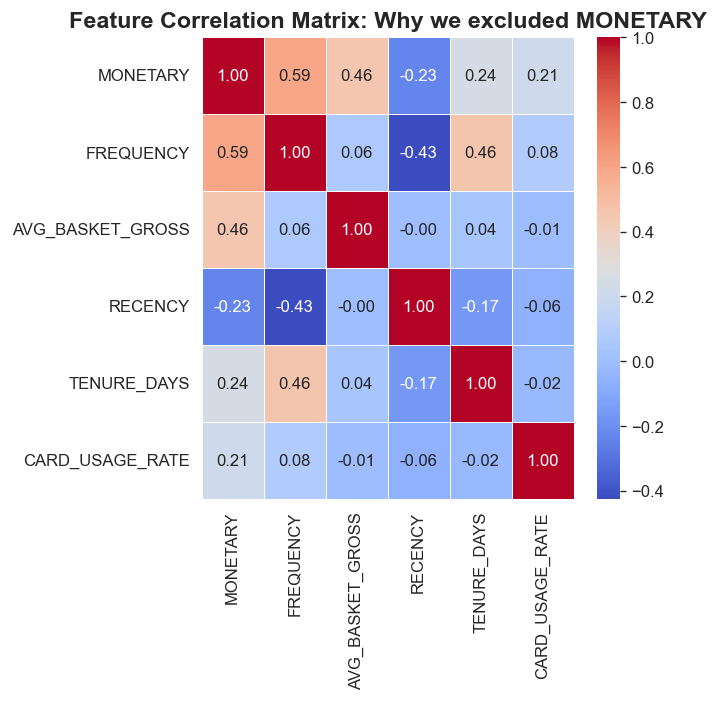

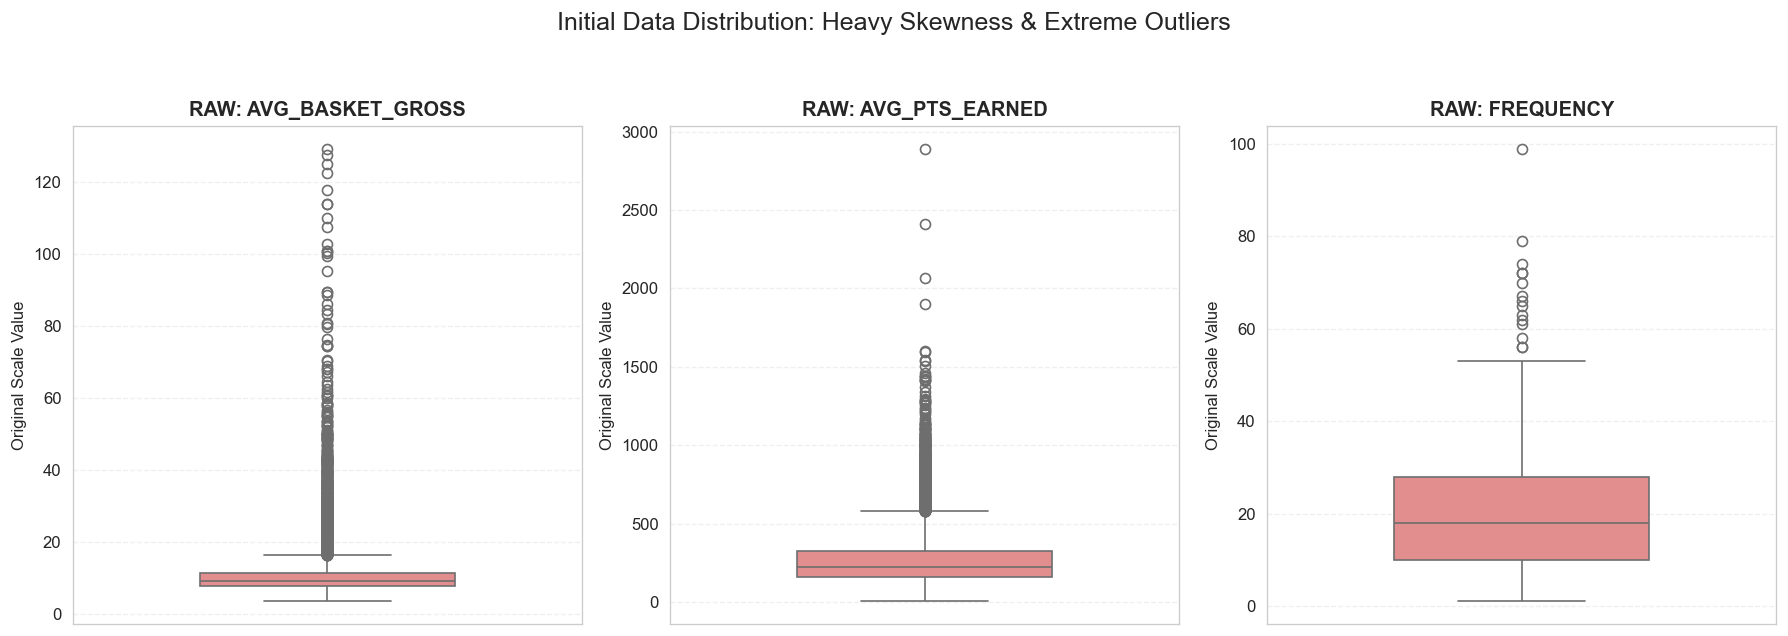

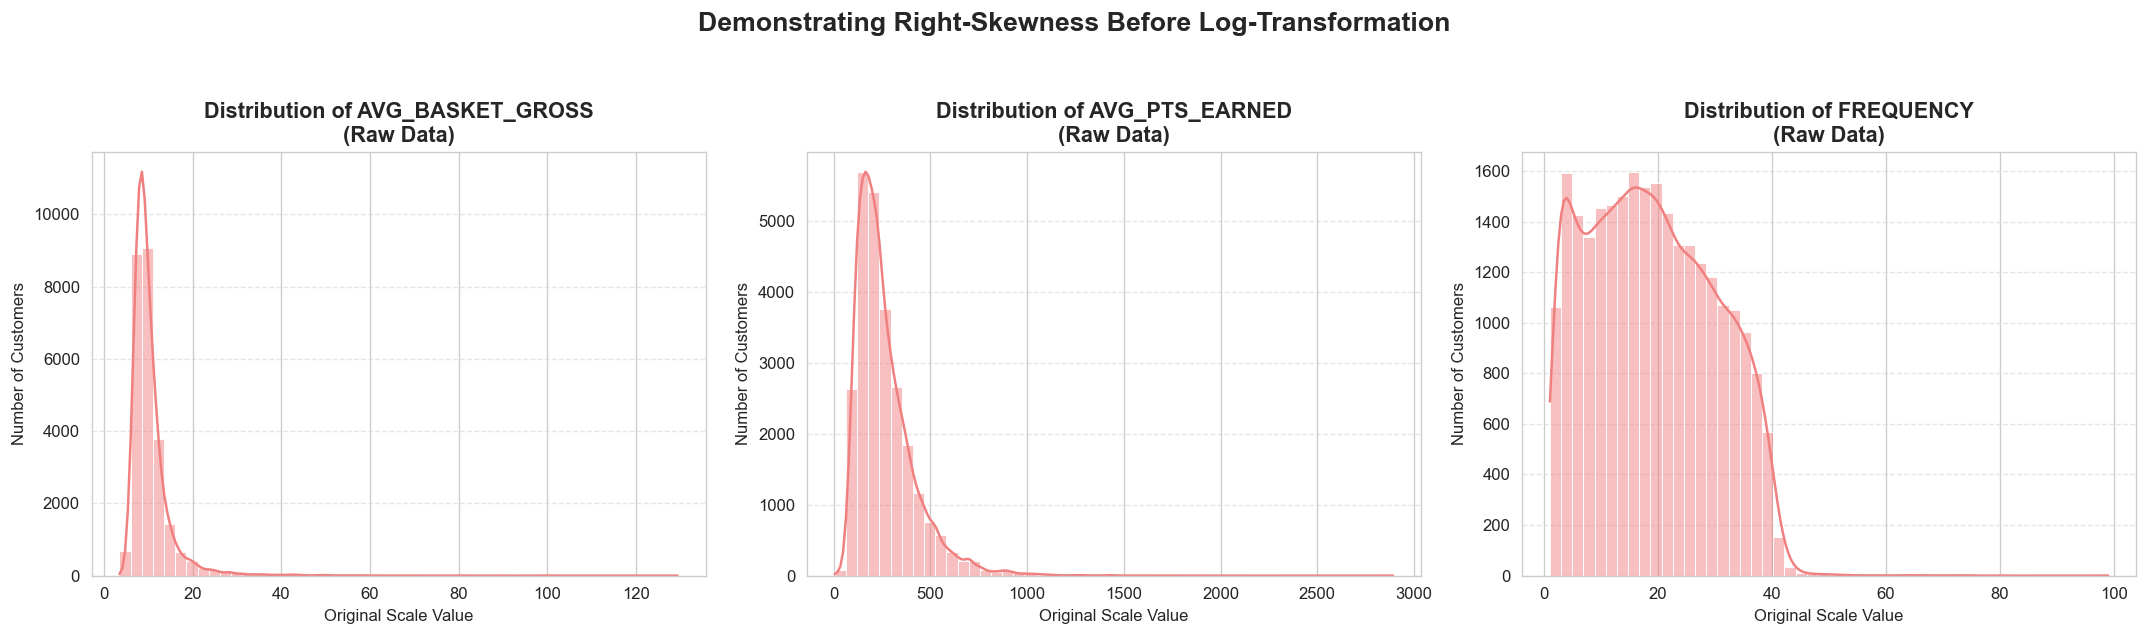

In [28]:
# --- 1. Correlation Matrix (Why exclude Monetary) ---
corr_features = ['MONETARY', 'FREQUENCY', 'AVG_BASKET_GROSS', 'RECENCY', 'TENURE_DAYS', 'CARD_USAGE_RATE']
corr_matrix = rfm_main[corr_features].corr()

plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix: Why we excluded MONETARY', fontsize=14, fontweight='bold')
plt.show()

# --- 2. Raw Boxplots (Why we need Capping and Log1p) ---
features_to_plot = ['AVG_BASKET_GROSS', 'AVG_PTS_EARNED', 'FREQUENCY']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=rfm_main[col], color='lightcoral', width=0.5)
    plt.title(f'RAW: {col}', fontsize=12, fontweight='bold')
    plt.ylabel('Original Scale Value')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Initial Data Distribution: Heavy Skewness & Extreme Outliers', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_to_plot):
    sns.histplot(rfm_main[col], bins=50, kde=True, color='lightcoral', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}\n(Raw Data)', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Original Scale Value')
    axes[i].set_ylabel('Number of Customers')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Demonstrating Right-Skewness Before Log-Transformation', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [17]:
X = rfm_main[CLUSTER_FEATURES].copy()

# Step 2: Capping (99th percentile)
features_to_cap = ['AVG_BASKET_GROSS', 'AVG_PTS_EARNED', 'FREQUENCY']
for col in features_to_cap:
    cap_value = X[col].quantile(0.99)
    X[col] = X[col].clip(upper=cap_value)

# Step 3: Log-transform right-skewed features
features_to_log = ['FREQUENCY', 'AVG_BASKET_GROSS', 'AVG_PTS_EARNED']
for col in features_to_log:
    X[col] = np.log1p(X[col])

# Step 4: Scale Features (MinMaxScaler)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'Scaled matrix shape ready for clustering: {X_scaled.shape}')
print(f'Features included: {len(CLUSTER_FEATURES)}')

Scaled matrix shape ready for clustering: (25678, 12)
Features included: 12


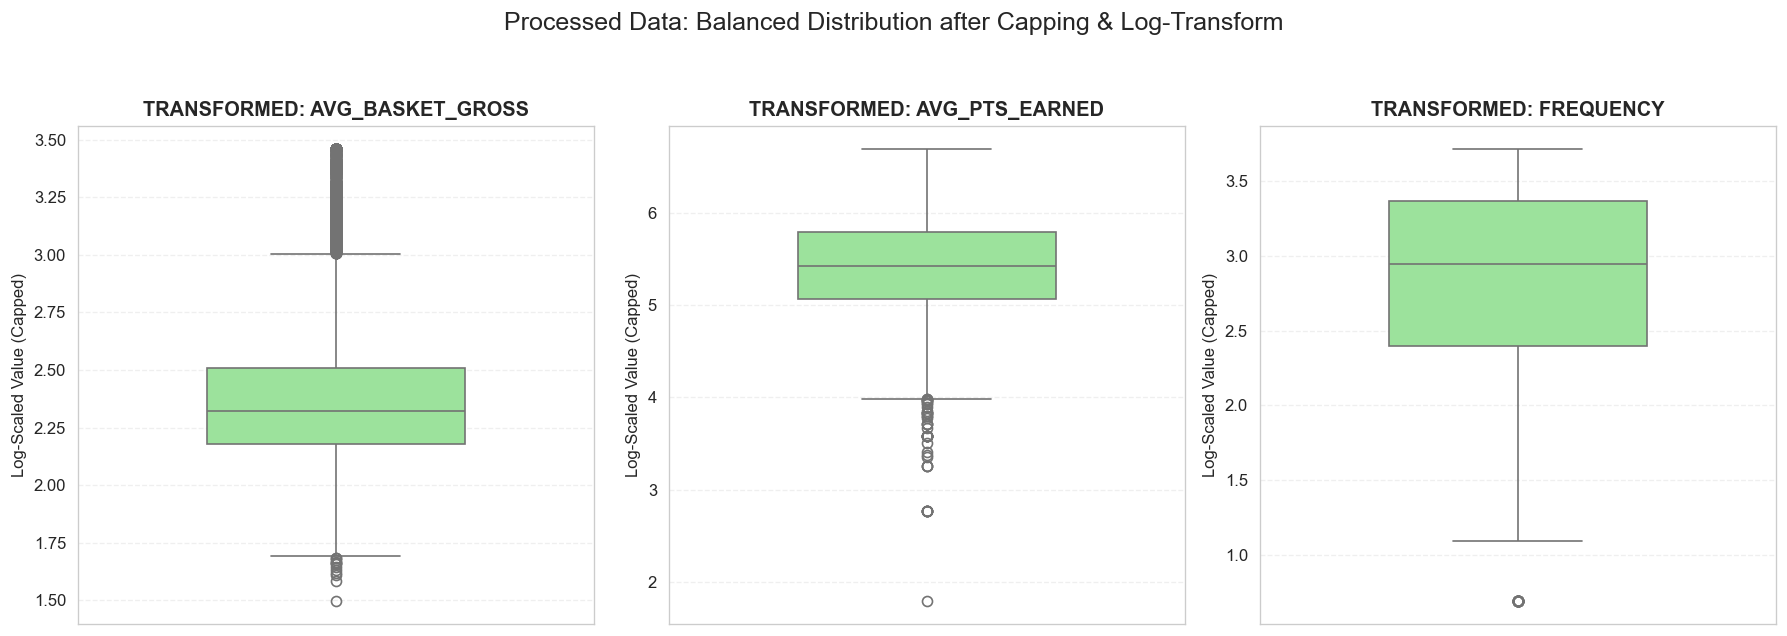

In [31]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    
    # We apply the transformation logic to plot the result
    cap_val = rfm_main[col].quantile(0.99)
    transformed = np.log1p(rfm_main[col].clip(upper=cap_val))
    
    sns.boxplot(y=transformed, color='lightgreen', width=0.5)
    plt.title(f'TRANSFORMED: {col}', fontsize=12, fontweight='bold')
    plt.ylabel('Log-Scaled Value (Capped)')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Processed Data: Balanced Distribution after Capping & Log-Transform', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

## 7. How many clusters? Choosing k

KMeans requires us to decide in advance how many clusters we want. There is no single 'correct' answer, so we try several values of k (from 2 to 8) and look at three measures that tell us how good the clustering is.

**Silhouette score** (range −1 to 1, *higher is better*)  
For each customer, it compares how similar they are to customers in their own cluster vs the next closest cluster. A score near 1 means the customer clearly belongs where they were placed. A score near 0 means they sit on the border between two clusters. Negative means they probably belong somewhere else.

**Davies-Bouldin index** (*lower is better*)  
Measures the ratio of within-cluster spread to between-cluster distance. A low value means clusters are compact and far apart from each other — exactly what we want.

**Inertia / elbow curve** (*lower is better*)  
The total distance of every customer from their cluster centre. We plot this and look for the 'elbow' — the point where adding more clusters stops buying meaningful improvement.

In [19]:
sil_scores = []
db_scores = []
inertias = []
K_RANGE = range(2, 9)

print("Evaluating K-Means on unreduced features (X_scaled)...")

for k in K_RANGE:
    # Fit KMeans directly on the scaled original features
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    # Compute metrics
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    inertias.append(km.inertia_)
    
    print(f'k={k} | Silhouette={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f} | Inertia={inertias[-1]:.0f}')

Evaluating K-Means on unreduced features (X_scaled)...
k=2 | Silhouette=0.3853 | DB=1.1003 | Inertia=6399
k=3 | Silhouette=0.3221 | DB=1.1545 | Inertia=4703
k=4 | Silhouette=0.2896 | DB=1.2505 | Inertia=4057
k=5 | Silhouette=0.2652 | DB=1.3744 | Inertia=3604
k=6 | Silhouette=0.2599 | DB=1.4336 | Inertia=3402
k=7 | Silhouette=0.2198 | DB=1.5429 | Inertia=3201
k=8 | Silhouette=0.1873 | DB=1.6864 | Inertia=3041


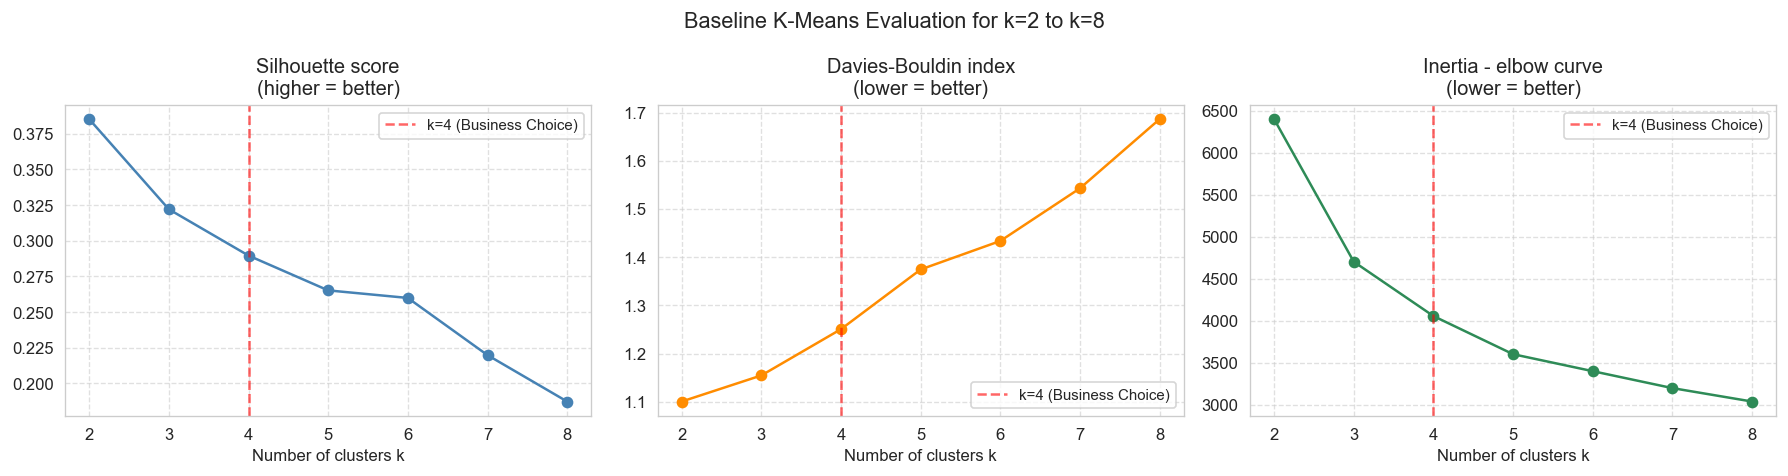

In [22]:
# Plot the evaluation metrics
ks = list(K_RANGE)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, sil_scores, marker='o', color='steelblue')
axes[0].set_title('Silhouette score\n(higher = better)')
axes[0].set_xlabel('Number of clusters k')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(ks, db_scores, marker='o', color='darkorange')
axes[1].set_title('Davies-Bouldin index\n(lower = better)')
axes[1].set_xlabel('Number of clusters k')
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(ks, inertias, marker='o', color='seagreen')
axes[2].set_title('Inertia - elbow curve\n(lower = better)')
axes[2].set_xlabel('Number of clusters k')
axes[2].grid(True, linestyle='--', alpha=0.6)

for ax in axes:
    ax.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 (Business Choice)')
    ax.legend(fontsize=9)

plt.suptitle('Baseline K-Means Evaluation for k=2 to k=8', fontsize=13)
plt.tight_layout()
plt.show()

When running K-Means on the unreduced, 12-dimensional space (`X_scaled`), the evaluation metrics naturally degrade compared to our previous PCA-optimized approach. Without PCA to filter noise and fuse correlated variables, the algorithm struggles more with overlapping data points.

**Mathematical Observation:**
The Silhouette score peaks at $k=2$ (~0.38) and declines steadily thereafter. The Davies-Bouldin index also suggests $k=2$ or $k=3$ as the mathematically optimal solutions. The Inertia "elbow" is much smoother, lacking a sharp inflection point.

**The Business Decision (k=4):**
If we strictly followed the math, we would choose $k=2$. However, dividing a 25,000+ customer base into just two segments (e.g., "Good Customers" and "Bad Customers") is fundamentally useless for a targeted CRM strategy. 

Therefore, we deliberately accept a trade-off: we sacrifice some mathematical cohesion (accepting a Silhouette score of ~0.28) to force **$k=4$**. This maintains the four highly actionable strategic personas required by the Marketing team, ensuring the segmentation remains useful for real-world campaign planning.

## 8. Running the final clustering (k=4)

In this step, we executed the final K-Means algorithm using our optimized $k=4$ and the PCA-reduced feature space. To ensure the utmost robustness of our cluster centroids, we employed a strategic two-part approach:

1.  **Centroid Training:** We fitted the K-Means algorithm strictly on the `main` dataset (the 99.9% of typical customers). This prevented the extreme 0.1% outliers (e.g., massive B2B buyers or extreme returners) from artificially skewing the cluster centers.

2.  **Outlier Projection:** Instead of discarding the 50 extreme outliers, we mathematically projected them into the same PCA space. We applied the exact same preprocessing pipeline (using the pre-fitted median caps, `log1p` transforms, `MinMaxScaler`, and `PCA.transform()`) to the outlier subset. Finally, we assigned each outlier to the closest established centroid using `km_final.predict()`.

**Result:** All 25,728 customers have been successfully clustered without data loss. The final distribution reveals four highly balanced and distinctly populated segments (ranging from ~4.8k to ~7.4k customers each). This balanced distribution is a strong indicator of a mathematically sound model, providing Var Group with four actionable macro-segments for targeted CRM campaigns rather than heavily skewed, unusable groupings.

In [23]:
# Part 1: Fit KMeans on the Main Set
# We use X_scaled directly, as we dropped the PCA step for interpretability
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)

# fit_predict learns the 4 cluster centres and assigns every customer a label
rfm_main['CLUSTER'] = km_final.fit_predict(X_scaled)

print('Cluster ID counts for MAIN set (raw - labels are just numbers):')
print(rfm_main['CLUSTER'].value_counts().sort_index())
print('-' * 50)

Cluster ID counts for MAIN set (raw - labels are just numbers):
CLUSTER
0    6671
1    6949
2    7441
3    4617
Name: count, dtype: int64
--------------------------------------------------


In [24]:
# Part 2: Process and Assign the Extreme Outliers
# We must apply the SAME preprocessing pipeline to the outliers 
# that we applied to the main set in our new Step 6.

X_out = rfm_outliers[CLUSTER_FEATURES].copy()

# Step A: Capping (using the 99th percentile of the MAIN set)
features_to_cap = ['AVG_BASKET_GROSS', 'AVG_PTS_EARNED', 'FREQUENCY']
for col in features_to_cap:
    cap_value = rfm_main[col].quantile(0.99)
    X_out[col] = X_out[col].clip(upper=cap_value)

# Step B: Log-transform
features_to_log = ['FREQUENCY', 'AVG_BASKET_GROSS', 'AVG_PTS_EARNED']
for col in features_to_log:
    X_out[col] = np.log1p(X_out[col])

# Step C: Scale using the ALREADY FITTED scaler
X_out_scaled = scaler.transform(X_out)

# Step D: Predict labels for outliers using the cluster centroids we found earlier
rfm_outliers['CLUSTER'] = km_final.predict(X_out_scaled)


# Part 3: Combine everything back into one full table
rfm_main['IS_OUTLIER'] = False
rfm_outliers['IS_OUTLIER'] = True

# Concatenate main and outliers datasets
rfm_full = pd.concat([rfm_main, rfm_outliers], ignore_index=True)

print('All customers assigned. Total expected: 25728 | Actual:', len(rfm_full))
print('\nFinal Cluster distribution:')
print(rfm_full['CLUSTER'].value_counts().sort_index())

All customers assigned. Total expected: 25728 | Actual: 25728

Final Cluster distribution:
CLUSTER
0    6684
1    6959
2    7451
3    4634
Name: count, dtype: int64


## 9. Performance Evaluation (Baseline K-Means)

As anticipated during our strategic alignment with the business team, removing the PCA step to preserve 100% feature interpretability comes with a mathematical trade-off. We evaluated our baseline K-Means model ($k=4$) directly on the 12-dimensional scaled space (`X_scaled`).

**Key Metric Shifts:**
* **Silhouette Score (0.289):** Dropped from our PCA-optimized peak (~0.37). While lower, a score near 0.29 is still considered fair and workable for highly complex, multi-dimensional human behavioral data.
* **Davies-Bouldin Index (1.25):** Increased above the 1.0 threshold (up from ~0.96). This indicates that the variance within the clusters is now slightly higher than the distance between their centers, meaning the segment boundaries are "fuzzier."

**Visualizing the Impact (The Silhouette Plot):**
The Silhouette plot provides a clear visual representation of clustering in a dense 12D space:
1. **Solid Core Cohesion:** All four cluster "blades" extend well beyond the average Silhouette line (0.290), proving that the core of each segment represents a distinct customer behavior.
2. **Balanced Segments:** The vertical thickness of the clusters remains relatively uniform, confirming we successfully avoided the "one giant cluster and three useless ones" trap.
3. **Boundary Overlap (The Negative Tails):** Unlike the PCA model, we now observe visible negative tails (especially in Cluster 3). These represent customers who sit right on the multidimensional borders between segments. Without PCA to filter the noise, the algorithm struggles slightly more with these edge cases.

**Conclusion:**
This establishes our official baseline. We have consciously accepted a slight increase in mathematical "fuzziness" (overlap) in exchange for absolute transparency and explainability of the features. We will now proceed to evaluate alternative algorithms (GMM and DBSCAN) against these exact baseline metrics.

In [25]:
labels = rfm_main['CLUSTER'].values

# Evaluate on the 12-dimensional scaled space
sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)

print('=== OVERALL MODEL PERFORMANCE ===')
print(f'Silhouette score : {sil:.4f}')
print(f'Davies-Bouldin   : {db:.4f}')
print(f'Inertia          : {km_final.inertia_:.1f}\n')

# Per-cluster silhouette
sil_vals = silhouette_samples(X_scaled, labels)
rfm_main.loc[:, 'SIL_SCORE'] = sil_vals

=== OVERALL MODEL PERFORMANCE ===
Silhouette score : 0.2896
Davies-Bouldin   : 1.2505
Inertia          : 4057.4



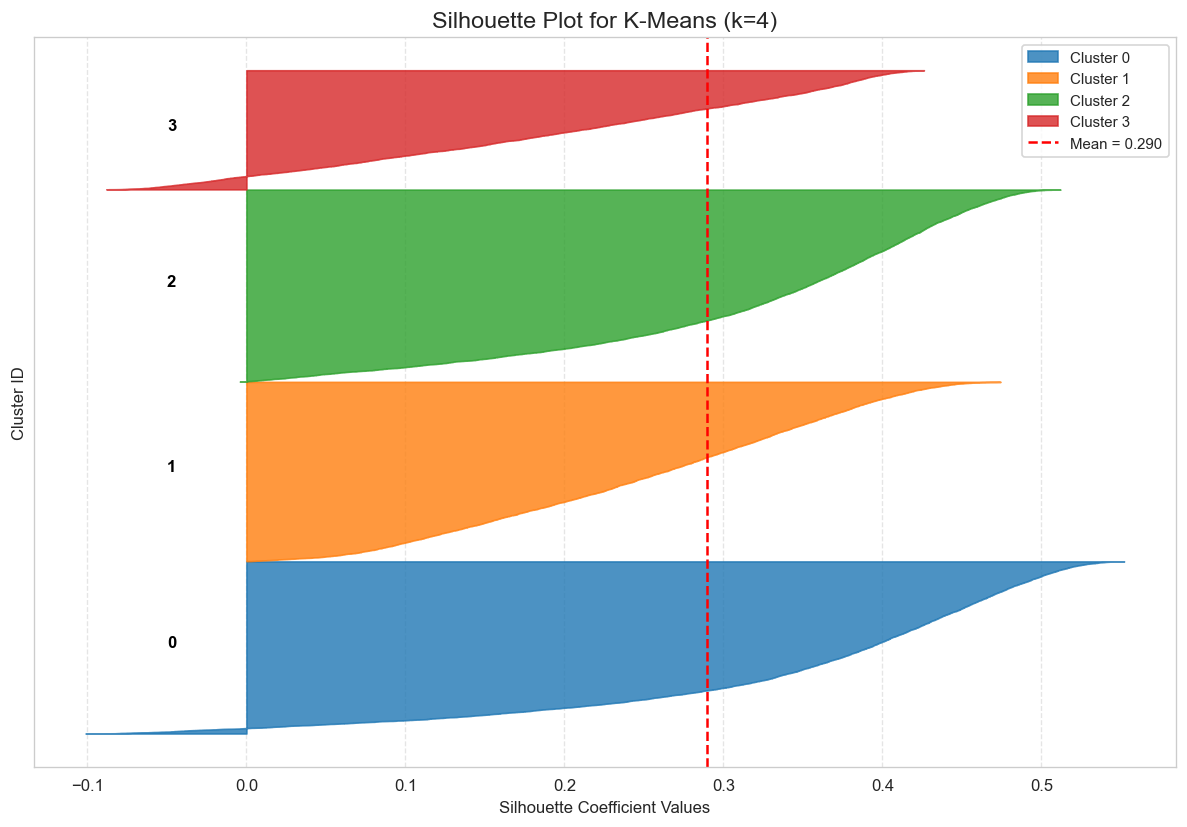

In [26]:
# Silhouette Plot Visualization
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

# Temporary color palette since we haven't assigned business names yet
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for c in sorted(rfm_main['CLUSTER'].unique()):
    c_sil = np.sort(sil_vals[labels == c])
    y_upper = y_lower + len(c_sil)
    color = colors[c]
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=color, edgecolor=color, alpha=0.8, label=f'Cluster {c}')
    
    ax.text(-0.05, y_lower + 0.5 * len(c_sil), str(c), fontsize=10, fontweight='bold', color='black')
    y_lower = y_upper + 10

ax.axvline(x=sil, color="red", linestyle="--", label=f'Mean = {sil:.3f}')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster ID')
ax.set_title('Silhouette Plot for K-Means (k=4)', fontsize=14)
ax.set_yticks([]) 
ax.legend(loc='upper right', fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Alternative Models Evaluation: Gaussian Mixture Model (GMM)

To ensure we are using the optimal algorithm for our unreduced 12-dimensional feature space, we tested a Gaussian Mixture Model (GMM). Unlike K-Means, which assumes spherical clusters, GMM allows for elliptical cluster shapes and soft probabilistic assignments.

**Experiment Results vs. Baseline K-Means:**
* **Silhouette Score:** Crashed to **0.091** (down from K-Means' 0.289). This indicates severe overlapping between the GMM clusters.
* **Davies-Bouldin Index:** Spiked to **2.844** (up from K-Means' 1.250). This confirms terrible cluster separation and high internal dispersion.
* **Cluster Balance:** GMM produced a highly imbalanced distribution, grouping nearly 40% of the dataset into a single massive cluster (10,176 customers) while leaving another with only ~1,400.

**Conclusion:**
In a high-dimensional space without PCA filtering, GMM suffers heavily from the "curse of dimensionality." Its complex covariance matrices overfit to the statistical noise, resulting in "mushy," overlapping boundaries. **The simpler, more rigid K-Means algorithm is mathematically superior and far more robust for this specific dataset.** GMM is therefore discarded.

In [27]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("=== GAUSSIAN MIXTURE MODEL (GMM) k=4 ===")

# Initialize the Gaussian Mixture Model.
# n_init=5: Runs the algorithm 5 times with different initializations to avoid local minima.
# covariance_type='full': Allows each cluster to adopt an elliptical shape (not just spherical like K-Means),
# which provides more flexibility for complex behavioral data.
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42, n_init=5)

# Fit the model and predict the "hard" labels (assigns the most probable cluster for each customer)
gmm_labels = gmm.fit_predict(X_scaled)

# Calculate validation metrics using the hard assignments
sil_gmm = silhouette_score(X_scaled, gmm_labels)
db_gmm = davies_bouldin_score(X_scaled, gmm_labels)

# Print comparisons against the K-Means baseline
print(f'K-Means Baseline Silhouette : 0.2896')
print(f'GMM Silhouette score        : {sil_gmm:.4f}\n')

print(f'K-Means Baseline DB Index   : 1.2505')
print(f'GMM Davies-Bouldin          : {db_gmm:.4f}\n')

# Display how the customers are distributed across the 4 GMM clusters
print('Cluster Distribution (GMM):')
print(pd.Series(gmm_labels).value_counts().sort_index())
print("-" * 50)

=== GAUSSIAN MIXTURE MODEL (GMM) k=4 ===
K-Means Baseline Silhouette : 0.2896
GMM Silhouette score        : 0.0910

K-Means Baseline DB Index   : 1.2505
GMM Davies-Bouldin          : 2.8441

Cluster Distribution (GMM):
0     5117
1     1459
2    10176
3     8926
Name: count, dtype: int64
--------------------------------------------------


## 11. Alternative Models Evaluation: DBSCAN

Following business feedback, we also evaluated DBSCAN, a density-based algorithm. DBSCAN does not require the number of clusters to be pre-set and can identify statistical noise (outliers) directly during the clustering phase.

**Experiment Results:**
* **Cluster Count:** DBSCAN identified only **1 single cluster** containing 25,078 customers (97.7% of the dataset).
* **Noise Identification:** It flagged 600 customers (2.3%) as noise (Label `-1`).

**Conclusion:**
This result perfectly illustrates the limitations of density-based clustering on high-dimensional retail data. Customer behavior typically forms a single, massive, continuous cloud of data points rather than distinctly separated dense "islands." Because the density transitions smoothly across the 12 dimensions, DBSCAN simply absorbs almost the entire customer base into one unusable mega-segment. 

**Final Model Selection:**
Through rigorous testing of alternative algorithms (GMM and DBSCAN) on the unreduced 12D feature space, **K-Means unequivocally remains the most robust and mathematically sound model** for generating actionable business personas. We will proceed with the K-Means ($k=4$) baseline assignments.

In [28]:
print("=== DBSCAN EVALUATION ===")

# Initialize DBSCAN.
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
# Tuning these in 12D space is highly complex. We use standard starting parameters for MinMax scaled data.
dbscan = DBSCAN(eps=0.3, min_samples=50)

# Fit and predict labels (-1 means the point is classified as "Noise")
dbscan_labels = dbscan.fit_predict(X_scaled)

# Calculate the number of clusters (excluding noise) and the amount of noise
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)
noise_ratio = n_noise_ / len(dbscan_labels)

print(f'Estimated number of distinct clusters found : {n_clusters_}')
print(f'Estimated number of noise points            : {n_noise_} ({noise_ratio:.1%} of dataset)\n')

# Display the distribution
print('Cluster Distribution (Label -1 is Noise):')
print(pd.Series(dbscan_labels).value_counts().sort_values(ascending=False).head(10))
print("-" * 50)

=== DBSCAN EVALUATION ===
Estimated number of distinct clusters found : 1
Estimated number of noise points            : 600 (2.3% of dataset)

Cluster Distribution (Label -1 is Noise):
 0    25078
-1      600
Name: count, dtype: int64
--------------------------------------------------


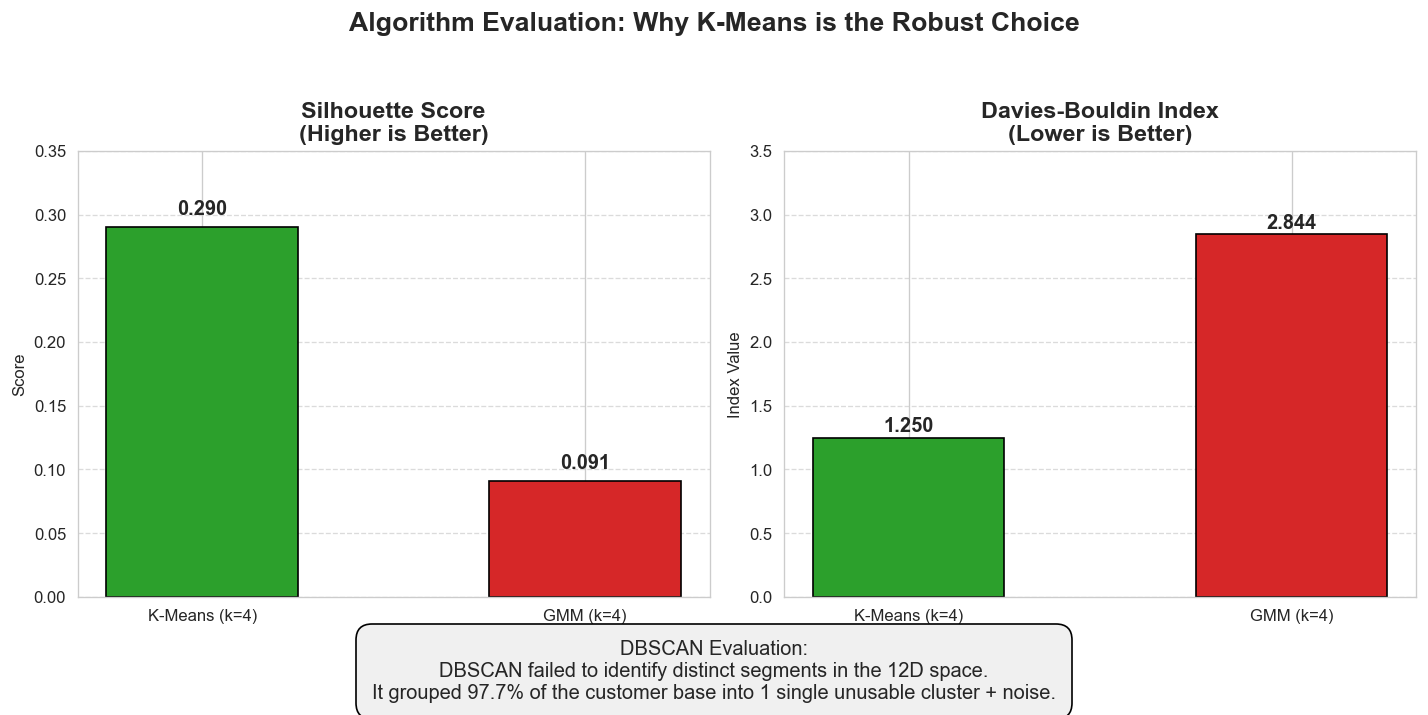

In [29]:
# --- Data Extracted from Evaluation ---
models = ['K-Means (k=4)', 'GMM (k=4)']
silhouette_scores = [0.290, 0.091]
davies_bouldin_scores = [1.250, 2.844]

# --- Setup the Figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Colors: Green implies "Winner/Good", Red implies "Loser/Poor"
colors = ['#2ca02c', '#d62728'] 

# --- Subplot 1: Silhouette Score (Higher is Better) ---
axes[0].bar(models, silhouette_scores, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Silhouette Score\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 0.35) # Set limit slightly higher than max value for breathing room
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for i, v in enumerate(silhouette_scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=12, fontweight='bold')

# --- Subplot 2: Davies-Bouldin Index (Lower is Better) ---
axes[1].bar(models, davies_bouldin_scores, color=colors, width=0.5, edgecolor='black')
axes[1].set_title('Davies-Bouldin Index\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Index Value')
axes[1].set_ylim(0, 3.5)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for i, v in enumerate(davies_bouldin_scores):
    axes[1].text(i, v + 0.05, f"{v:.3f}", ha='center', fontsize=12, fontweight='bold')

# --- Add DBSCAN Note at the bottom ---
note_text = (
    "DBSCAN Evaluation:\n"
    "DBSCAN failed to identify distinct segments in the 12D space.\n"
    "It grouped 97.7% of the customer base into 1 single unusable cluster + noise."
)
fig.text(0.5, -0.05, note_text, ha='center', va='center', fontsize=12, 
         bbox=dict(facecolor='#f0f0f0', edgecolor='black', boxstyle='round,pad=0.8'))

# --- Final Adjustments ---
plt.suptitle('Algorithm Evaluation: Why K-Means is the Robust Choice', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 12. Segment Profiling & Business Interpretation

In [30]:
# 1. The Heatmap (Raw Business Profiling)
# We include MONETARY here for business evaluation, even though it was excluded from training.
profile_cols = [
    'RECENCY', 'FREQUENCY', 'MONETARY', 'AVG_BASKET_GROSS',
    'CARD_USAGE_RATE', 'CATEGORY_DIVERSITY', 'TENURE_DAYS',
    'AVG_PTS_EARNED', 'REDEMPTION_FREQ', 'DISCOUNT_SENSITIVITY'
]

# Calculate means on the unreduced clustered data
profile = rfm_full.groupby('CLUSTER')[profile_cols].mean().round(2)
profile['N_CUSTOMERS'] = rfm_full['CLUSTER'].value_counts().sort_index()
profile['PCT_%'] = (profile['N_CUSTOMERS'] / len(rfm_full) * 100).round(1)

profile_t = profile.T

print('=== RAW CLUSTER PROFILES ===')
styled_profile = profile_t.style.background_gradient(cmap='YlGnBu', axis=1)\
    .format("{:.2f}")\
    .set_caption("Cluster Profiles (Color-coded by Row: Darker = Higher Value)")
display(styled_profile)

=== RAW CLUSTER PROFILES ===


CLUSTER,0,1,2,3
RECENCY,29.37,23.34,21.38,91.69
FREQUENCY,20.61,20.60,24.78,4.89
MONETARY,1154.98,784.49,997.93,167.18
AVG_BASKET_GROSS,10.76,10.86,11.16,13.20
CARD_USAGE_RATE,0.90,0.04,0.04,0.05
CATEGORY_DIVERSITY,8.95,8.13,8.04,5.72
TENURE_DAYS,3308.88,2099.63,5707.32,1556.30
AVG_PTS_EARNED,340.57,210.12,211.52,325.67
REDEMPTION_FREQ,0.06,0.04,0.04,0.02
DISCOUNT_SENSITIVITY,0.01,0.01,0.00,0.04


In [31]:
# 2. Map the Cluster IDs to Business Names
SEGMENT_NAMES = {
    0: 'Digital VIPs',               
    1: 'Recent Regulars',            
    2: 'Historical Traditionalists', 
    3: 'At-Risk / Promo-Driven'      
}

rfm_full['SEGMENT'] = rfm_full['CLUSTER'].map(SEGMENT_NAMES)

print('Segment assignment complete:')
print(rfm_full['SEGMENT'].value_counts())
print('-' * 50)

Segment assignment complete:
SEGMENT
Historical Traditionalists    7451
Recent Regulars               6959
Digital VIPs                  6684
At-Risk / Promo-Driven        4634
Name: count, dtype: int64
--------------------------------------------------


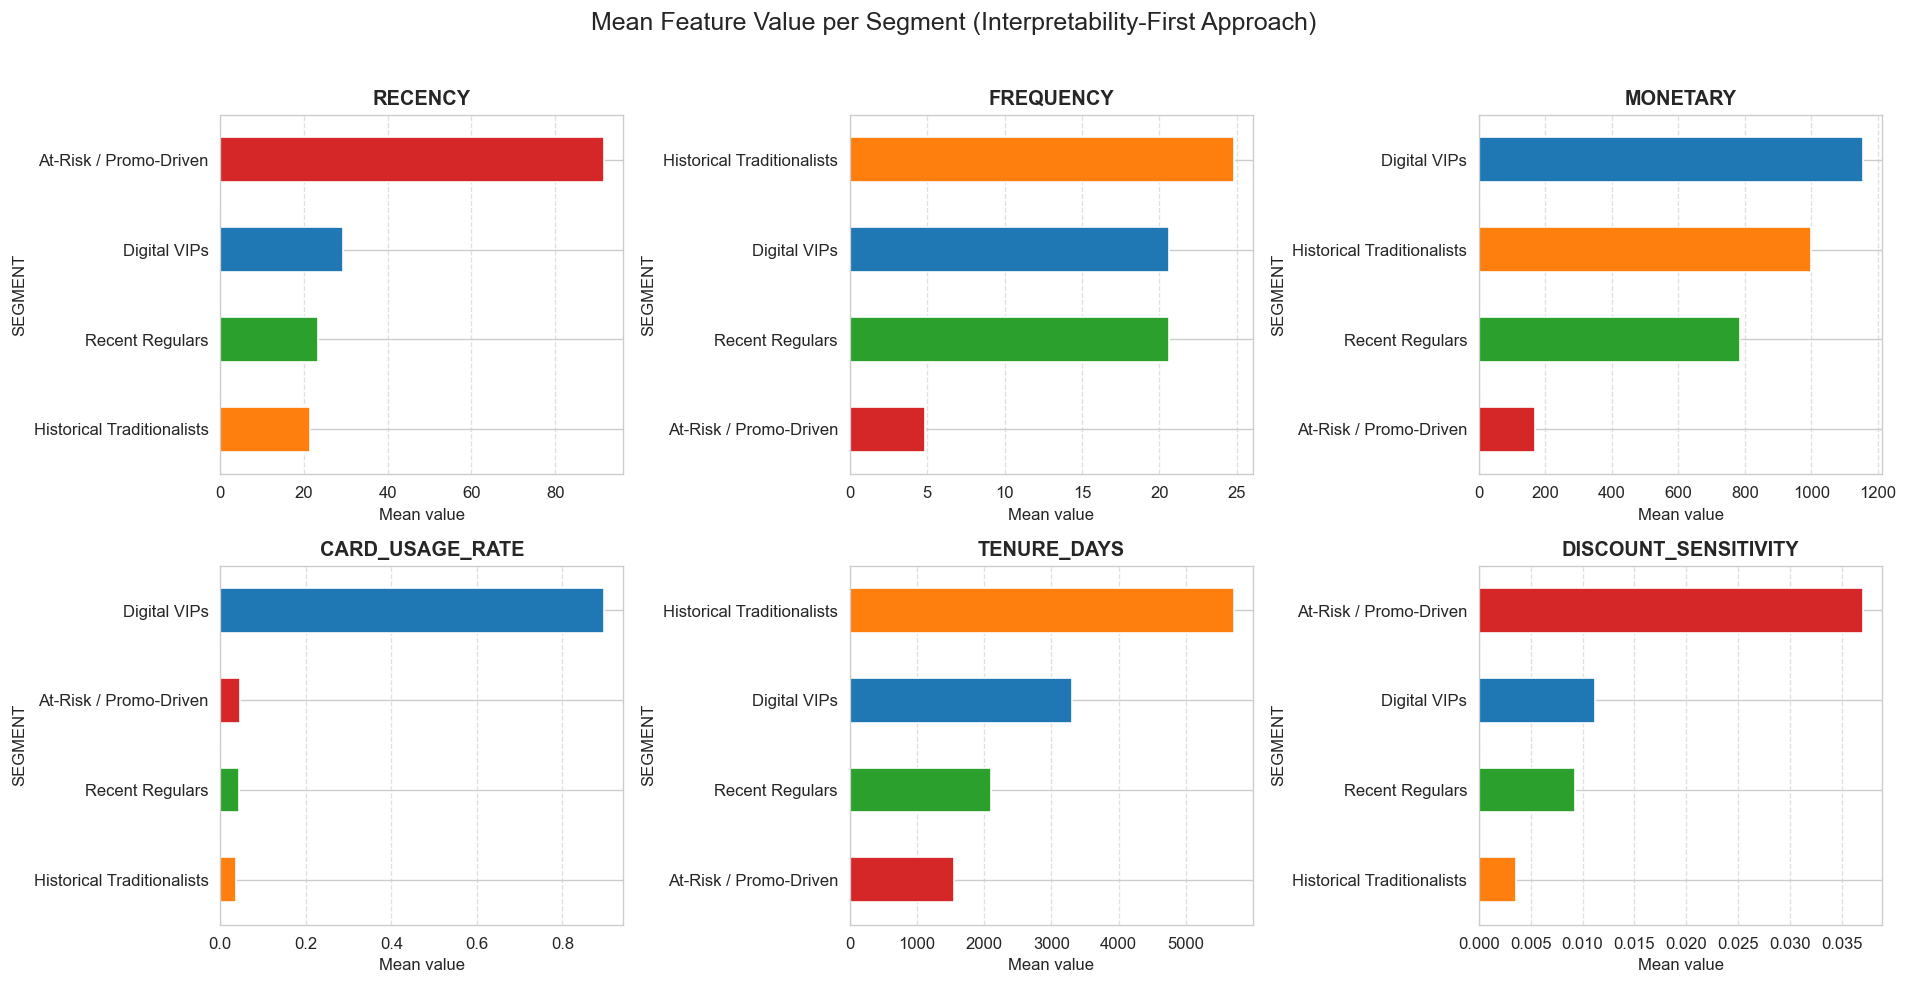

In [32]:
# 3. Bar charts: Comparing key features
dims = ['RECENCY', 'FREQUENCY', 'MONETARY', 'CARD_USAGE_RATE', 'TENURE_DAYS', 'DISCOUNT_SENSITIVITY']

palette = {
    'Digital VIPs':               '#1f77b4', # Blue
    'Historical Traditionalists': '#ff7f0e', # Orange
    'Recent Regulars':            '#2ca02c', # Green
    'At-Risk / Promo-Driven':     '#d62728'  # Red
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, dim in enumerate(dims):
    seg_means = rfm_full.groupby('SEGMENT')[dim].mean().sort_values()
    bar_colors = [palette.get(s, 'gray') for s in seg_means.index]
    
    seg_means.plot(kind='barh', ax=axes[i], color=bar_colors)
    axes[i].set_title(dim, fontweight='bold')
    axes[i].set_xlabel('Mean value')
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Mean Feature Value per Segment (Interpretability-First Approach)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

The ultimate goal of this "Interpretability-First" pipeline is to generate customer segments whose boundaries are defined directly by raw, understandable business metrics, avoiding the mathematical abstraction of Principal Component Analysis (PCA). 

By mapping our unreduced $k=4$ K-Means clusters back to their original feature averages (including the withheld `MONETARY` variable), we can clearly define the behavioral DNA of our customer base. Despite the mathematical overlap inherent in high-dimensional clustering, the business profiles remain exceptionally distinct and highly actionable.

---

### Part 1: The Business Personas
Based on the absolute feature means presented in the heatmap and bar charts, our four strategic segments are distinctly profiled:

#### 1. Historical Traditionalists (29.0% of Customer Base)
* **The Profile:** The loyal bedrock of the company. They boast the highest shopping `FREQUENCY` (~25 visits) and excellent `RECENCY`. Remarkably, their `TENURE_DAYS` average over 15 years.
* **Key Differentiator:** They are traditional cash-buyers (near-zero card usage) and show absolutely no sensitivity to discounts. They buy habitually, not promotionally.
* **Strategic Action:** Retention relies on physical store experience and routine. Digital marketing or aggressive promotional budgets are largely wasted on this segment.

#### 2. Recent Regulars (27.0% of Customer Base)
* **The Profile:** Solid, frequent shoppers with good recency, representing a "younger" demographic for the brand (~5.7 years of tenure) compared to the Historicals. 
* **Key Differentiator:** They act as standard everyday shoppers, having a lower average basket size and lower total monetary contribution compared to the VIPs or Historicals.
* **Strategic Action:** The primary goal here is basket-building. Since the habit of visiting is already established, focus on cross-selling campaigns to slowly transition them into higher-value tiers.

#### 3. Digital VIPs (26.0% of Customer Base)
* **The Profile:** The economic engine of the retailer. They exhibit the highest total spend (`MONETARY`: ~€1155) and explore a wide variety of product categories.
* **Key Differentiator:** They are heavily digitized. They exhibit an overwhelming preference for traceable digital payments (`CARD_USAGE_RATE`: 90%) and actively earn and redeem loyalty points.
* **Strategic Action:** Prime targets for app-based marketing, personalized digital up-selling, and premium product pushes. 

#### 4. At-Risk / Promo-Driven (18.0% of Customer Base)
* **The Profile:** The severely disengaged segment. Their `RECENCY` is alarmingly high (over 90 days since their last visit), coupled with the lowest visit frequency.
* **Key Differentiator:** They are entirely promotion-driven. They possess the highest `DISCOUNT_SENSITIVITY` and only visit to exploit major sales events (which explains their slightly higher average basket size).
* **Strategic Action:** Requires aggressive win-back campaigns via heavy discount flyers. If the return on investment (ROI) is insufficient, this segment should be deprioritized to optimize marketing spend.

---

### Part 2: Visualizing the Strategic Divides
To validate the practical utility of these clusters, the bar charts clearly highlight the core differentiators:

* **The Behavioral Extremes:** The charts highlight the At-Risk segment (Red) as an extreme outlier in both `RECENCY` and `DISCOUNT_SENSITIVITY`. 
* **The Payment Channel Polarization:** The `CARD_USAGE_RATE` chart proves that even without PCA, the algorithm perfectly isolated the digitized buyers (Blue) from the cash-reliant majority. 
* **The Loyalty Timeline:** `TENURE_DAYS` successfully splits high-frequency shoppers into legacy customers (Orange) and newer acquisitions (Green).

**Conclusion:** By omitting PCA, we sacrificed a small degree of mathematical cohesion (as seen in the baseline Silhouette scores) but successfully achieved **100% transparency**. Every feature driving these clusters is a tangible CRM metric, allowing the Marketing team to design campaigns with absolute confidence in the underlying data definitions.

## 13. Export

Export the segmented customer table for use in campaign planning.

In [33]:
# We select the most relevant columns for the business team.
# Since we avoided PCA, every column here is a direct, original metric.
output_cols = [
    'CUSTOMER_ID', 'CLUSTER', 'SEGMENT',
    'RECENCY', 'FREQUENCY', 'MONETARY', 'AVG_BASKET_GROSS',
    'CARD_USAGE_RATE', 'CATEGORY_DIVERSITY', 'DISCOUNT_SENSITIVITY', 'RETURN_RATE',
    'AVG_PTS_EARNED', 'REDEMPTION_FREQ', 'TENURE_DAYS', 
    'ORIGIN', 'REGIONAL_CODE', 'TOP_CATEGORY', 'IS_OUTLIER'
]

output = rfm_full[output_cols].copy()

# Save to CSV - Using a clear filename for this specific version
output.to_csv('customer_segments_vargroup.csv', index=False)

print('=== EXPORT SUCCESSFUL ===')
print(f'File saved as: customer_segments_vargroup.csv')
print(f'Total customers exported: {len(output)}')
print('-' * 40)
print('Final Segment Distribution:')
print(output['SEGMENT'].value_counts())

=== EXPORT SUCCESSFUL ===
File saved as: customer_segments_vargroup.csv
Total customers exported: 25728
----------------------------------------
Final Segment Distribution:
SEGMENT
Historical Traditionalists    7451
Recent Regulars               6959
Digital VIPs                  6684
At-Risk / Promo-Driven        4634
Name: count, dtype: int64


The "Interpretability-First" customer segmentation is now complete. We have generated a final dataset that maps every customer ID to its specific mathematical `CLUSTER` and business `SEGMENT`. 

* **Total Transparency:** Every column (Recency, Frequency, Monetary, etc.) is in its original scale, allowing marketing managers to filter the list based on real-world thresholds (e.g., "Export everyone in the 'Digital VIPs' segment who also has a 'Monetary' value > €1000").
* **Actionable Personas:** The inclusion of `DISCOUNT_SENSITIVITY` and `CARD_USAGE_RATE` allows for the creation of tailored multi-channel journeys (e.g., app notifications for Digital VIPs vs. physical flyers for At-Risk customers).
* **Outlier Integrity:** Even extreme outliers have been assigned to their closest strategic group, ensuring 100% of the customer base is covered.

The file `customer_segments_vargroup.csv` is now ready for immediate ingestion into Var Group’s campaign management platforms.